In [1]:
import cupy as cp
import numpy as np

In [2]:
backward_solve_SDE = cp.ElementwiseKernel(
    'float32 k, float32 C',
    'float32 x_next',
    r'''
    const double pi = 3.141592653589793238462643383279502884;
    const double a  = 2.0 * pi;

    double kk = (double)k;
    double cc = (double)C;
    double x;

    if (fabs(kk) < 1.0e-100) {
        x = cc;
    } else {
        const double b = pi;   // drift center

        const double A = 1.0 + kk;
        const double B = -(cc + a + kk * (a + b));
        const double G = a * cc + a * b * kk - 2.0 * kk;
        const double D = a * kk;

        const double p = (3.0 * A * G - B * B) / (3.0 * A * A);
        const double q = (2.0 * B * B * B - 9.0 * A * B * G + 27.0 * A * A * D)
                       / (27.0 * A * A * A);

        const double Delta = 0.25 * q * q + (p * p * p) / 27.0;
        const double shift = -B / (3.0 * A);

        if (Delta >= 0.0) {
            const double s1 = rcbrt_double(-0.5 * q + sqrt(Delta));
            const double s2 = rcbrt_double(-0.5 * q - sqrt(Delta));
            x = s1 + s2 + shift;
        } else {
            const double rho = 2.0 * sqrt(-p / 3.0);
            double arg = (-0.5 * q) / sqrt(-((p / 3.0) * (p / 3.0) * (p / 3.0)));

            // important for numerical safety
            if (arg > 1.0) arg = 1.0;
            if (arg < -1.0) arg = -1.0;

            const double phi = acos(arg);

            const double r0 = rho * cos(phi / 3.0) + shift;
            const double r1 = rho * cos((phi + 2.0 * pi) / 3.0) + shift;
            const double r2 = rho * cos((phi + 4.0 * pi) / 3.0) + shift;

            double best = 0.0;
            double fbest = 0.0;
            bool found = false;

            if (r0 > 0.0 && r0 < a) {
                double fr = fabs(Fval(r0, kk, cc, a, pi));
                best = r0;
                fbest = fr;
                found = true;
            }
            if (r1 > 0.0 && r1 < a) {
                double fr = fabs(Fval(r1, kk, cc, a, pi));
                if (!found || fr < fbest) {
                    best = r1;
                    fbest = fr;
                    found = true;
                }
            }
            if (r2 > 0.0 && r2 < a) {
                double fr = fabs(Fval(r2, kk, cc, a, pi));
                if (!found || fr < fbest) {
                    best = r2;
                    fbest = fr;
                    found = true;
                }
            }

            if (found) {
                x = best;
            } else {
                x = nan("");
            }
        }
    }

    x_next = (float)x;
    ''',
    'backward_solve_SDE',
    preamble=r'''
    __device__ inline double rcbrt_double(double z) {
        return (z >= 0.0) ? cbrt(z) : -cbrt(-z);
    }

    __device__ inline double Fval(double x, double k, double C, double a, double pi) {
        return x - C - k * (pi - x + 1.0 / x + 1.0 / (x - a));
    }
    '''
)

In [3]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

# -------------------------------------------------
# Define your drift pieces on GPU
# -------------------------------------------------
def f(r):
    return cp.pi - r

def wall_rep(r):
    return 1.0 / r + 1.0 / (r - 2.0 * cp.pi)


# -------------------------------------------------
# Simulate one batch on GPU without storing paths
# Returns number of moments differences for ST and IM at each time step
# -------------------------------------------------
def moment_estimating(n_paths, n_steps, T=100.0, mu=1, epsilon=1, dtype=cp.float32, nbr_moments=5):
    dt = T / n_steps
    sqrt_dt = np.sqrt(dt)
    sqrt_epsilon = np.sqrt(epsilon)
    k = 2.0 * mu * dt
    x_ST = cp.full(n_paths, cp.pi, dtype=dtype)
    x_CST = cp.full(n_paths, cp.pi, dtype=dtype)
    x_IM = cp.full(n_paths, cp.pi, dtype=dtype)
    moment_sum_ST_diff = cp.zeros((nbr_moments, n_steps), dtype=dtype)
    moment_sum_CST_diff = cp.zeros((nbr_moments, n_steps), dtype=dtype)
    moment_sum_IM_diff = cp.zeros((nbr_moments, n_steps), dtype=dtype)
    prob_ST_left = cp.zeros(n_steps, dtype=dtype)
    prob_CST_left = cp.zeros(n_steps, dtype=dtype)
    prob_IM_left = cp.zeros(n_steps, dtype=dtype)

    for step in range(n_steps):
        
        noise_term = 2*sqrt_epsilon*sqrt_dt * cp.random.randn(n_paths, dtype=dtype)
        
        C = x_IM+noise_term

        x_IM = backward_solve_SDE(k, C)

        x_ST = x_ST + 2.0 * mu * (f(x_ST) + wall_rep(x_ST)) * dt + noise_term
        x_CST = cp.clip(x_CST + 2.0 * mu * (f(x_CST) + wall_rep(x_CST)) * dt + noise_term, 1e-30, 2.0 * cp.pi-1e-30)
        
        prob_ST_left[step] = cp.mean(x_ST <= cp.pi)
        prob_CST_left[step] = cp.mean(x_CST <= cp.pi)
        prob_IM_left[step] = cp.mean(x_IM <= cp.pi)
        # Compute odds differences for moments
        for m in range(nbr_moments):
            moment_sum_ST_diff[m, step] = cp.mean((x_ST - cp.pi)**(2*m+1))
            moment_sum_CST_diff[m, step] = cp.mean((x_CST - cp.pi)**(2*m+1))
            moment_sum_IM_diff[m, step] = cp.mean((x_IM - cp.pi)**(2*m+1))


    return (
        moment_sum_ST_diff,
        moment_sum_CST_diff,
        moment_sum_IM_diff,
        prob_ST_left,
        prob_CST_left,
        prob_IM_left,
    )

import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

# -------------------------------------------------
# Plot empirical odd centered moments over time
# -------------------------------------------------
def plot_moment_evolution(moment_sum_ST_diff, moment_sum_CST_diff, moment_sum_IM_diff, n_paths, T, nbr_moments=5):
    """
    moment_sum_ST_diff, moment_sum_IM_diff:
        arrays of shape (nbr_moments, n_steps)
        storing sum_j (X_t^{(j)} - pi)^{2m+1}
    """

    # Move to CPU and convert sums -> empirical moments
    moment_ST = cp.asnumpy(moment_sum_ST_diff)
    moment_CST = cp.asnumpy(moment_sum_CST_diff)
    moment_IM = cp.asnumpy(moment_sum_IM_diff)

    nbr_moments, n_steps = moment_ST.shape
    times = np.linspace(T / n_steps, T, n_steps)

    for m in range(nbr_moments):
        power = 2 * m + 1

        plt.figure(figsize=(9, 5))
        plt.plot(times, moment_ST[m], label=f"Standard Euler, power={power}", color="blue")
        plt.plot(times, moment_CST[m], linestyle="-.", label=f"Clipped Standard Euler, power={power}", alpha=0.9, color="orange")
        plt.plot(times, moment_IM[m], linestyle="--", label=f"Backward Euler, power={power}", alpha=0.9, color="green")
        plt.axhline(0.0, linewidth=1, label="Exact value = 0")
        plt.xlabel("Time")
        plt.ylabel(rf"Empirical moment $E[(X_t-\pi)^{{{power}}}]$")
        plt.title(f"Odd centered moment of order {power} over time")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


In [4]:
n_paths = 10**6
n_steps = 6*10**5
T = 600.0
mu = 0.01
epsilon = 0.01
nbr_moments = 4

moment_sum_ST_diff, moment_sum_CST_diff, moment_sum_IM_diff, prob_ST_left, prob_CST_left, prob_IM_left = moment_estimating(
    n_paths=n_paths,
    n_steps=n_steps,
    T=T,
    mu=mu,
    epsilon=epsilon,
    dtype=cp.float32, 
    nbr_moments=nbr_moments
)


In [5]:
# Plot probability estimates P(X_t <= pi) over time
# -------------------------------------------------
def plot_probability_evolution(prob_ST_left, prob_CST_left, prob_IM_left, T):
    prob_ST = cp.asnumpy(prob_ST_left)
    prob_CST = cp.asnumpy(prob_CST_left)
    prob_IM = cp.asnumpy(prob_IM_left)

    n_steps = prob_ST.shape[0]
    times = np.linspace(T / n_steps, T, n_steps)

    plt.figure(figsize=(10, 5))
    plt.plot(times, prob_ST, label=r"Standard Euler: $\hat P(X_t \leq \pi)$", alpha=1)
    plt.plot(times, prob_CST, label=r"Clipped Euler: $\hat P(X_t \leq \pi)$", linestyle="--", alpha=1)
    plt.plot(times, prob_IM, label=r"Backward Euler: $\hat P(X_t \leq \pi)$", linestyle="-.", color="green")
    plt.axhline(0.5, color="black", linewidth=1, label="Exact value = 1/2")
    plt.xlabel("Time")
    plt.ylabel(r"Empirical probability $\hat P(X_t \leq \pi)$")
    plt.title(r"Probability estimate of $P(X_t \leq \pi)$ over time")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

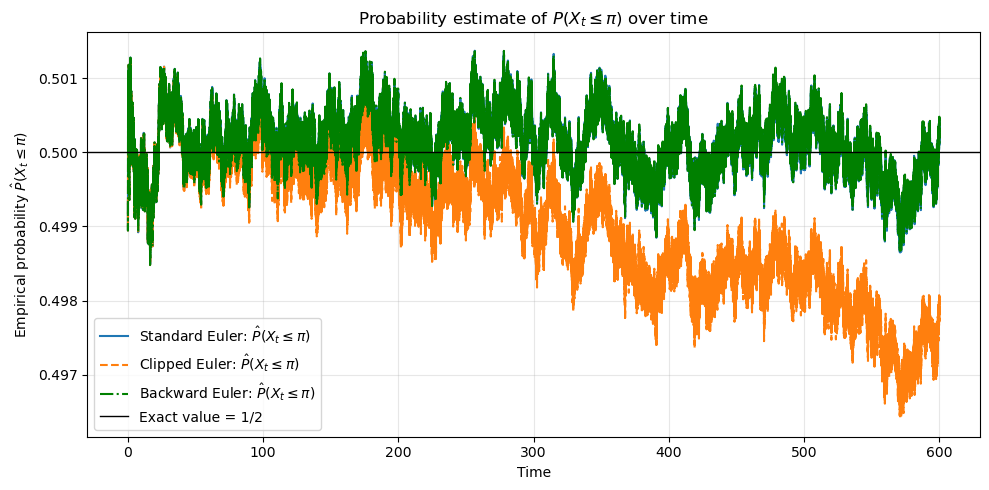

In [6]:
plot_probability_evolution(prob_ST_left, prob_CST_left, prob_IM_left, T)

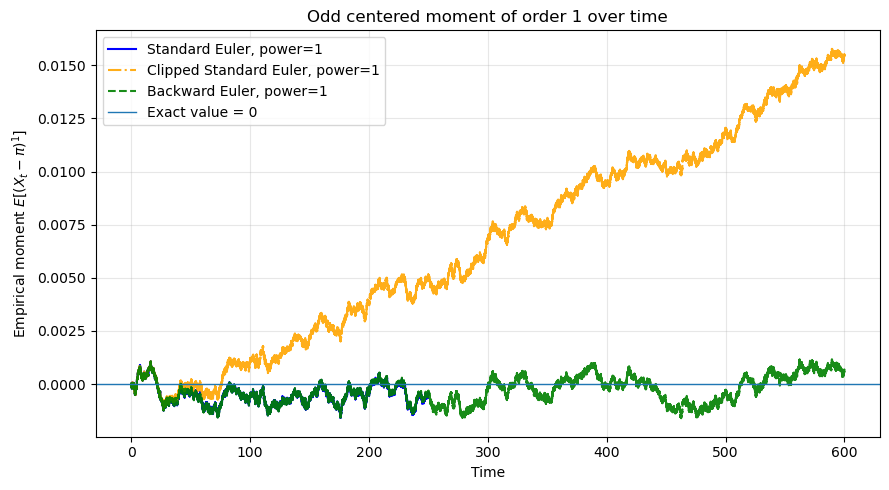

C:\Users\johan\AppData\Local\Temp\ipykernel_35112\3250934535.py:99: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


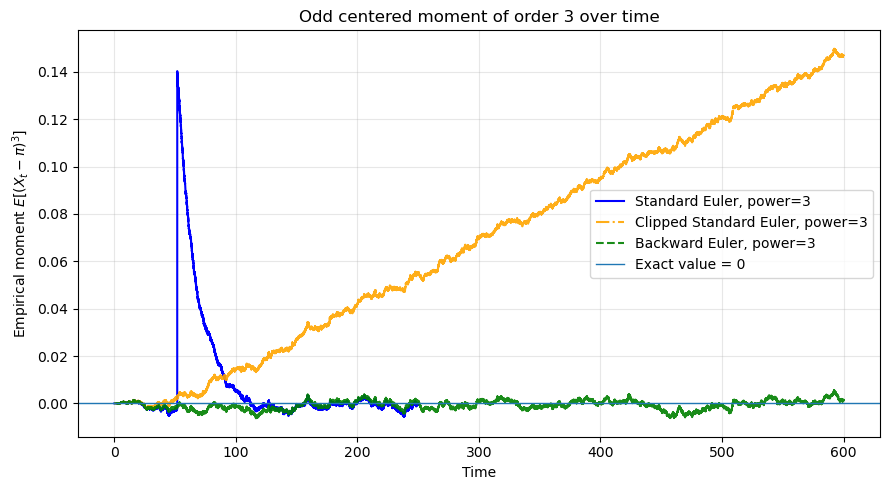

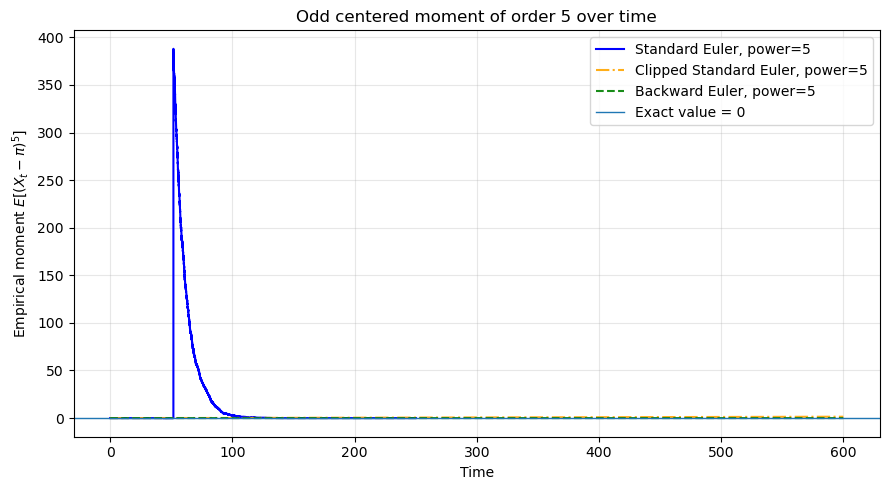

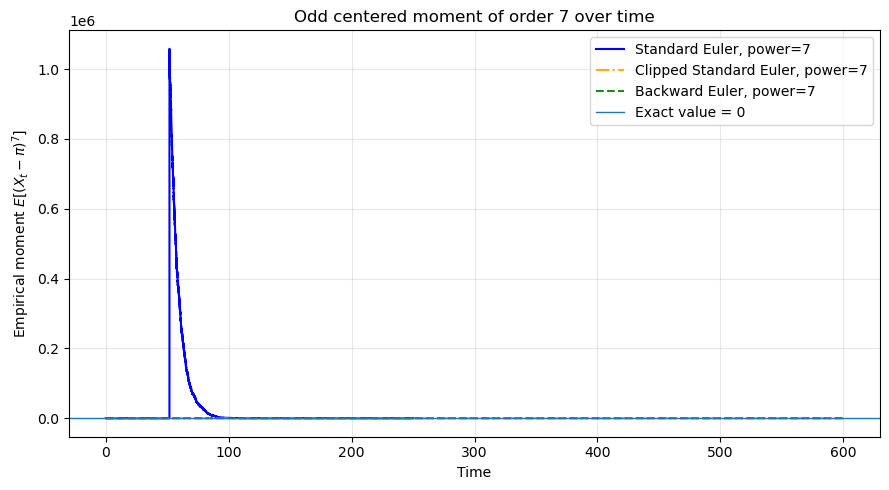

In [7]:

plot_moment_evolution(moment_sum_ST_diff,moment_sum_CST_diff, moment_sum_IM_diff, n_paths, T,nbr_moments=nbr_moments)

In [8]:
# -------------------------------------------------
# Plot empirical odd centered moments over time
# Standard Euler above, Implicit below
# -------------------------------------------------
def plot_moment_evolution_stacked(moment_sum_ST_diff, moment_sum_CST_diff, moment_sum_IM_diff, n_paths, T):
    """
    moment_sum_ST_diff, moment_sum_IM_diff:
        arrays of shape (nbr_moments, n_steps)
        storing sum_j (X_t^{(j)} - pi)^{2m+1}
    """

    # Move to CPU and convert sums -> empirical moments
    moment_ST = cp.asnumpy(moment_sum_ST_diff) 
    moment_CST = cp.asnumpy(moment_sum_CST_diff)
    moment_IM = cp.asnumpy(moment_sum_IM_diff) 

    nbr_moments, n_steps = moment_ST.shape
    times = np.linspace(T / n_steps, T, n_steps)

    for m in range(nbr_moments):
        power = 2 * m + 1

        fig, axes = plt.subplots(
            2, 1,
            figsize=(10, 7),
            sharex=True,
            constrained_layout=True
        )

        # -------------------------
        # Standard Euler
        # -------------------------
        axes[0].plot(times, moment_ST[m], label=f"Standard Euler, power={power}")
        axes[0].axhline(0.0, linewidth=1, label="Exact value = 0")
        axes[0].set_ylabel(rf"$E[(X_t-\pi)^{{{power}}}]$")
        axes[0].set_title(f"Standard Euler, odd centered moment of order {power}")
        axes[0].grid(True, alpha=0.3)
        axes[0].legend()
        # -------------------------
        # Standard Clipped Euler
        # -------------------------
        axes[1].plot(times, moment_CST[m], linestyle="-.", label=f"Clipped Standard Euler, power={power}", alpha=0.9, color="orange")
        axes[1].axhline(0.0, linewidth=1, label="Exact value = 0")
        axes[1].set_xlabel("Time")          
        axes[1].set_title(f"Clipped Standard Euler and Backward Euler, odd centered moment of order {power}")
        axes[1].grid(True, alpha=0.3)
        axes[1].legend()
        # -------------------------
        # Implicit Euler
        # -------------------------
        axes[1].plot(times, moment_IM[m], linestyle="--", label=f"Backward Euler, power={power}", alpha=0.9, color="green")
        axes[1].set_xlabel("Time")
        axes[1].set_ylabel(rf"$E[(X_t-\pi)^{{{power}}}]$")
        axes[1].grid(True, alpha=0.3)
        axes[1].legend()

        plt.show()

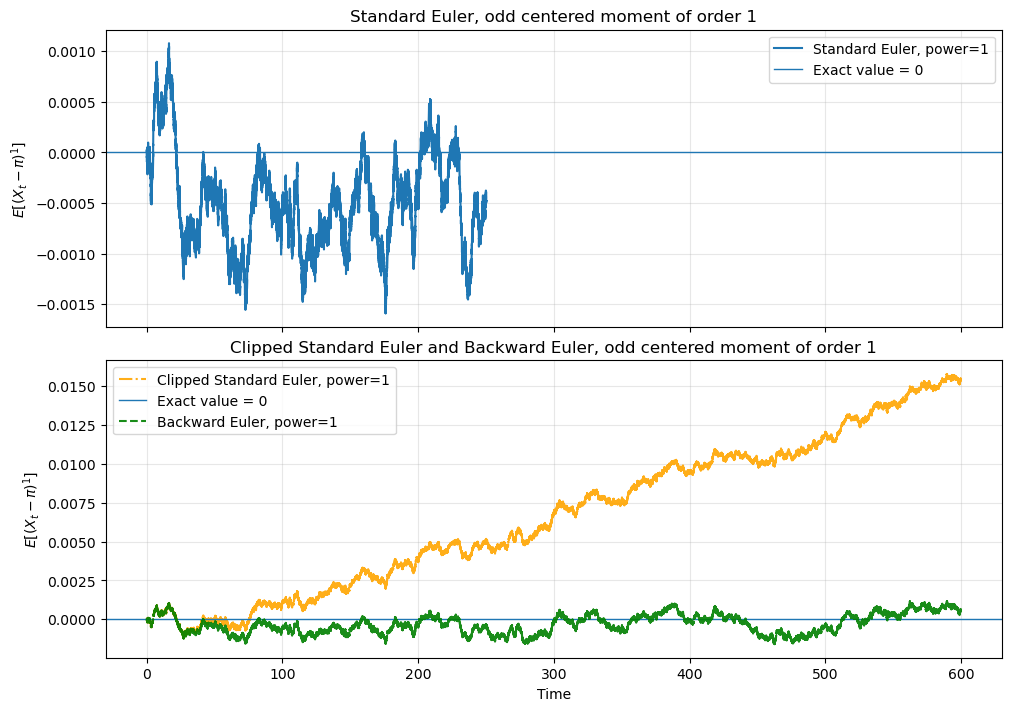

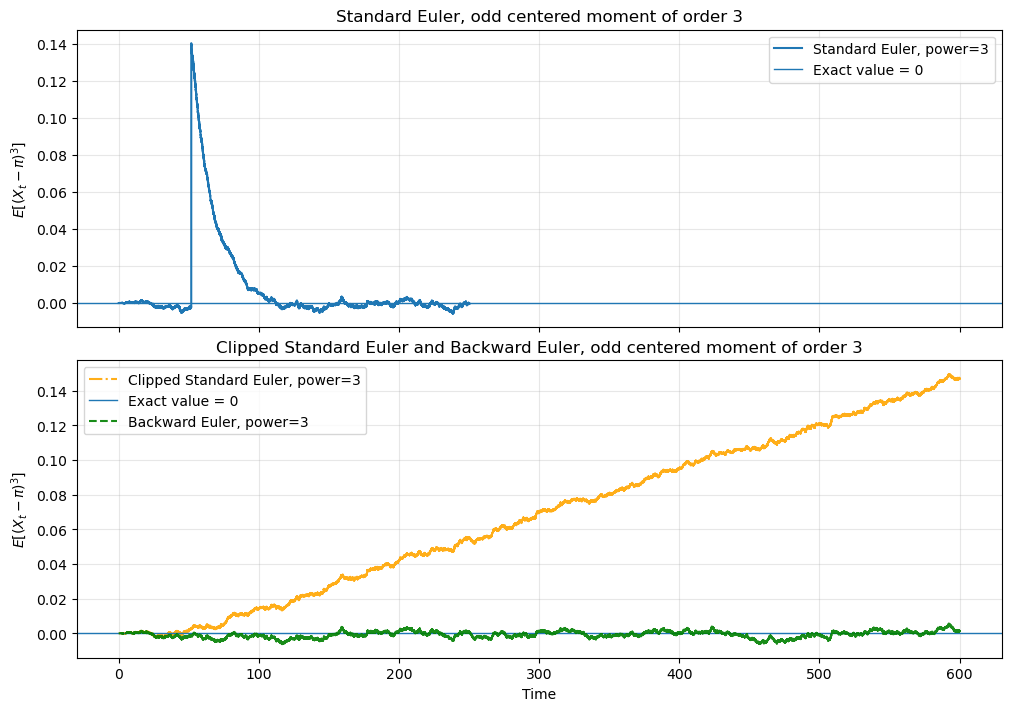

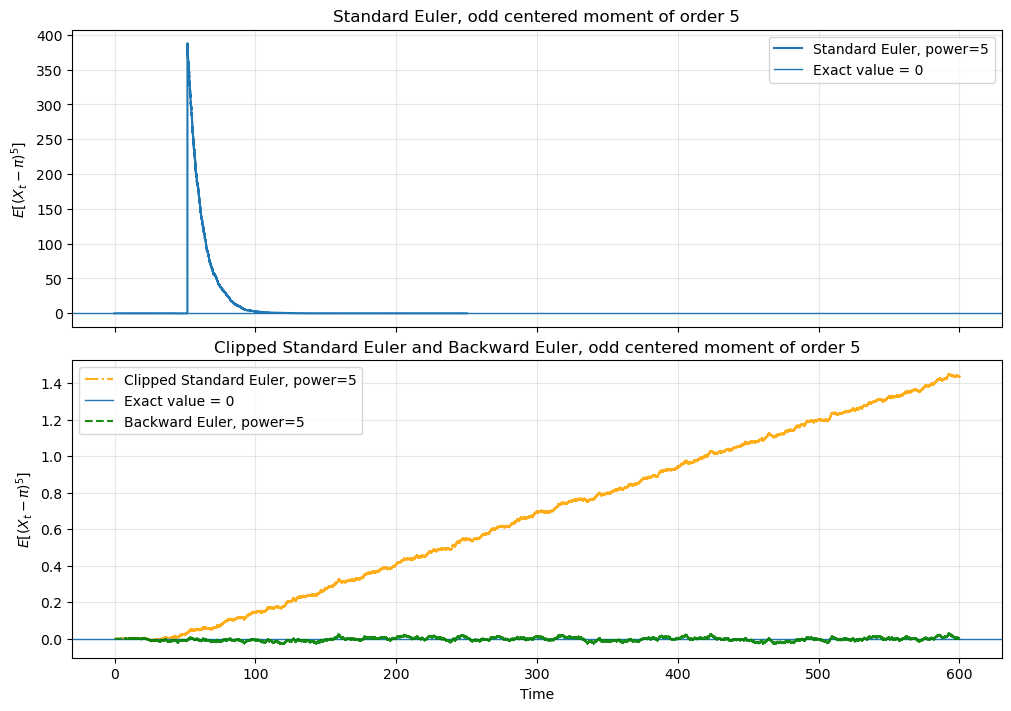

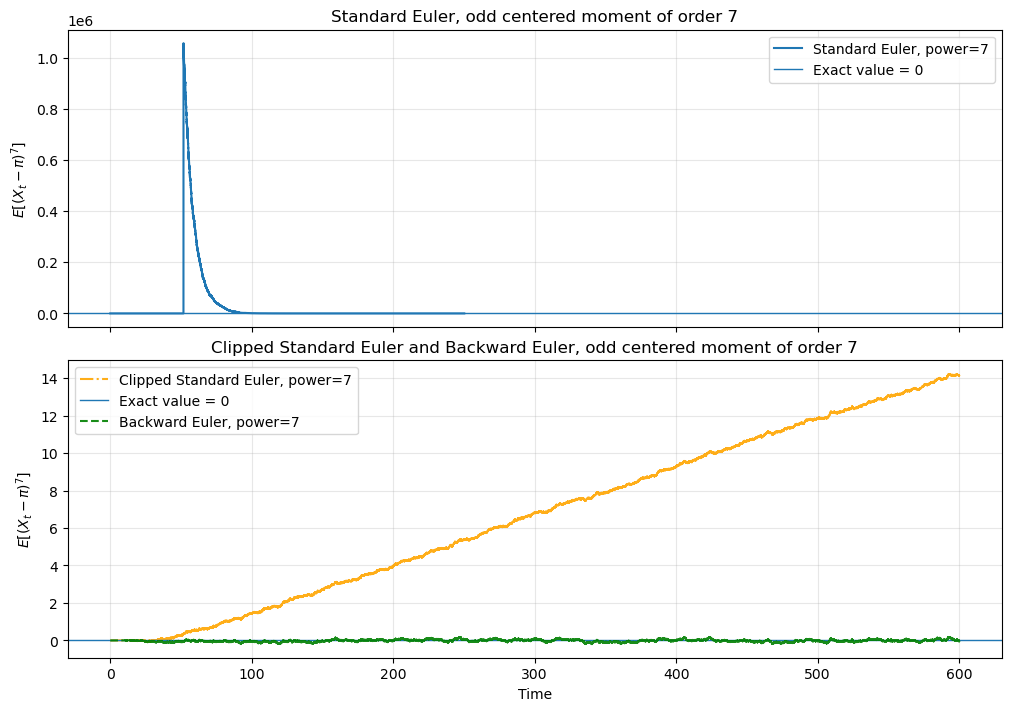

In [9]:
plot_moment_evolution_stacked(moment_sum_ST_diff, moment_sum_CST_diff, moment_sum_IM_diff, n_paths, T)

In [18]:
# -------------------------------------------------
# Plot empirical odd centered moments over time
# Standard Euler above, Implicit below
# -------------------------------------------------
def plot_moment_backward_only(moment_sum_IM_diff, n_paths, T):
    """
    moment_sum_IM_diff:
        arrays of shape (nbr_moments, n_steps)
        storing sum_j (X_t^{(j)} - pi)^{2m+1}
    """

    # Move to CPU and convert sums -> empirical moments
    moment_IM = cp.asnumpy(moment_sum_IM_diff) 

    nbr_moments, n_steps = moment_IM.shape
    times = np.linspace(T / n_steps, T, n_steps)

    for m in range(nbr_moments):
        power = 2 * m + 1

        fig, axes = plt.subplots(
            1, 1,
            figsize=(10, 7),
            sharex=True,
            constrained_layout=True
        )

        #--------
        # Implicit Euler
        # -------------------------
        axes.plot(times, moment_IM[m], label=f"Backward Euler, power={power}", alpha=0.9)
        axes.set_xlabel("Time")
        axes.set_ylabel(rf"$E[(X_t-\pi)^{{{power}}}]$")
        axes.grid(True, alpha=0.3)
        axes.legend()

        plt.show()

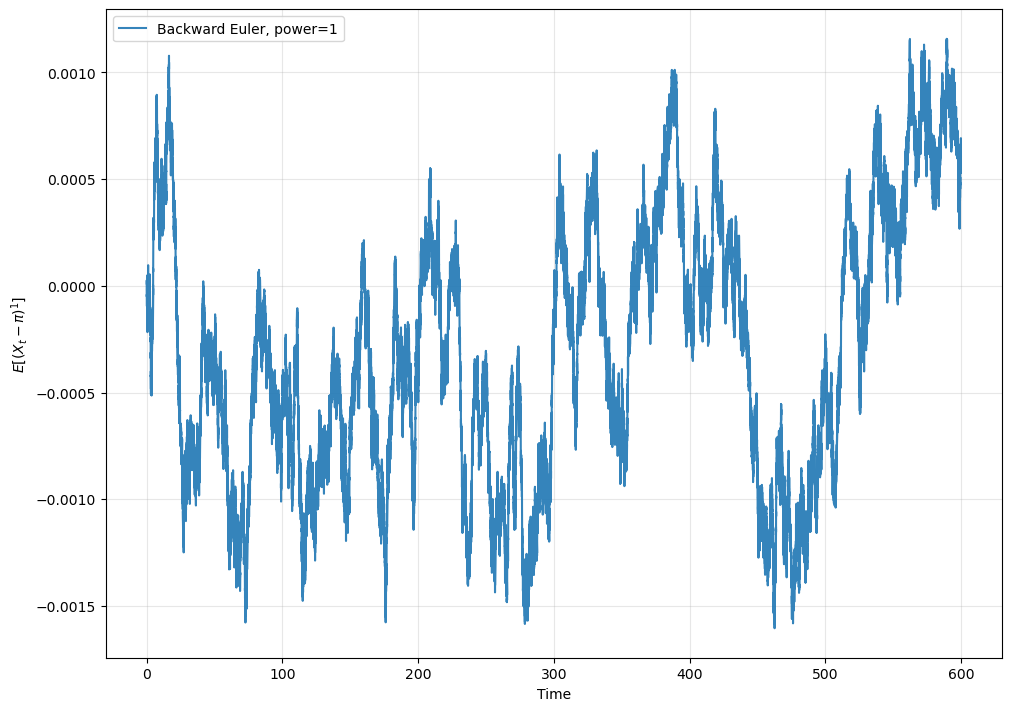

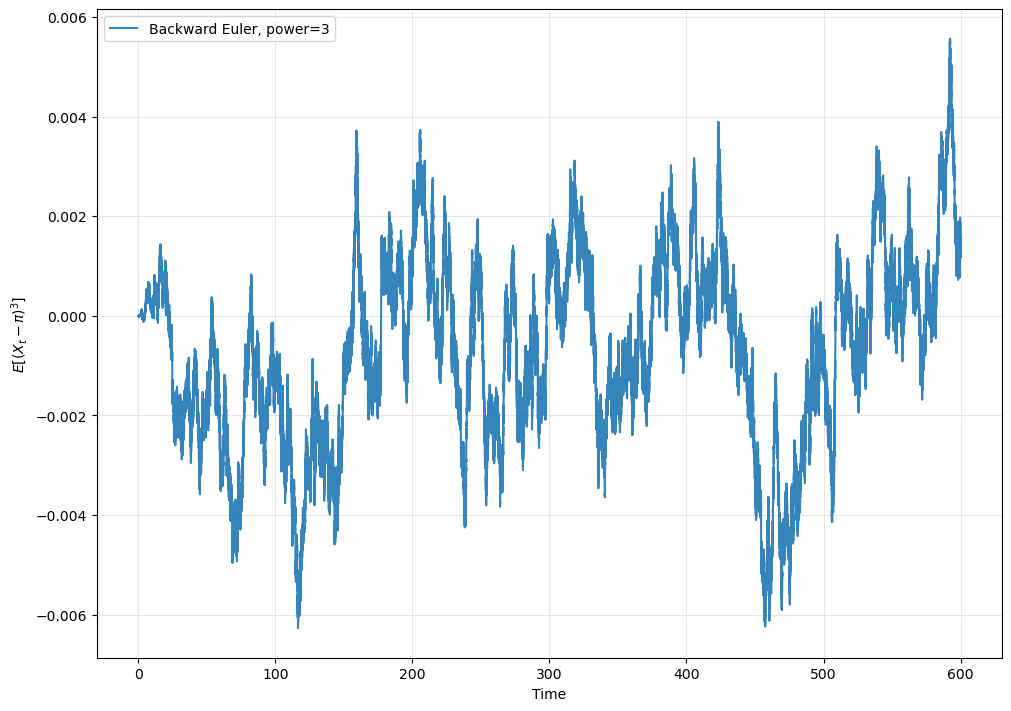

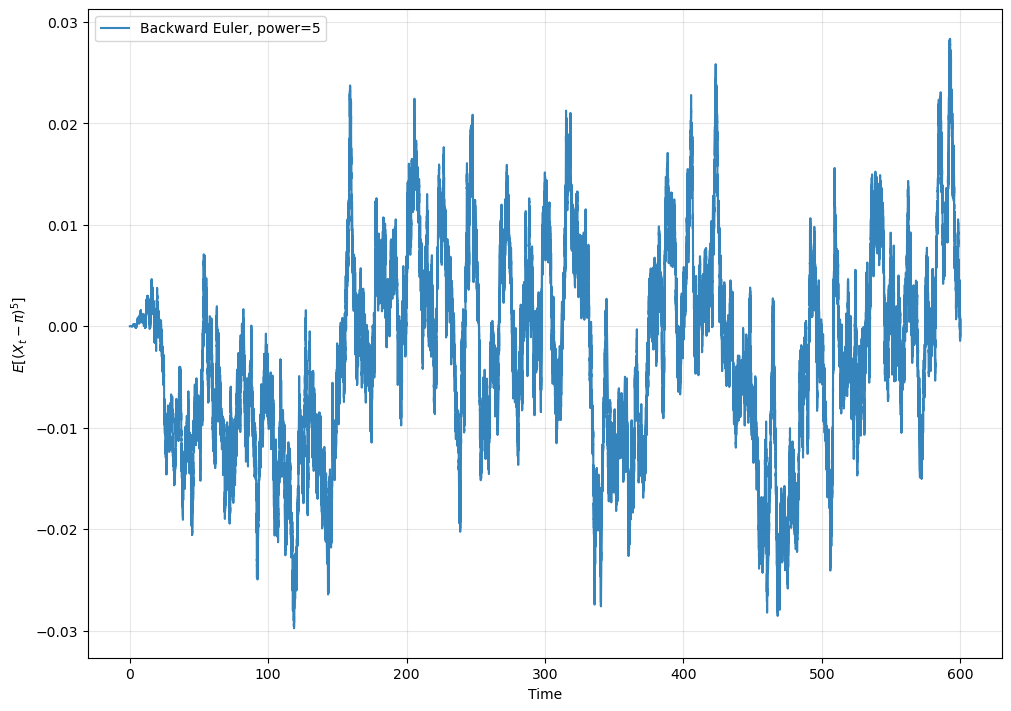

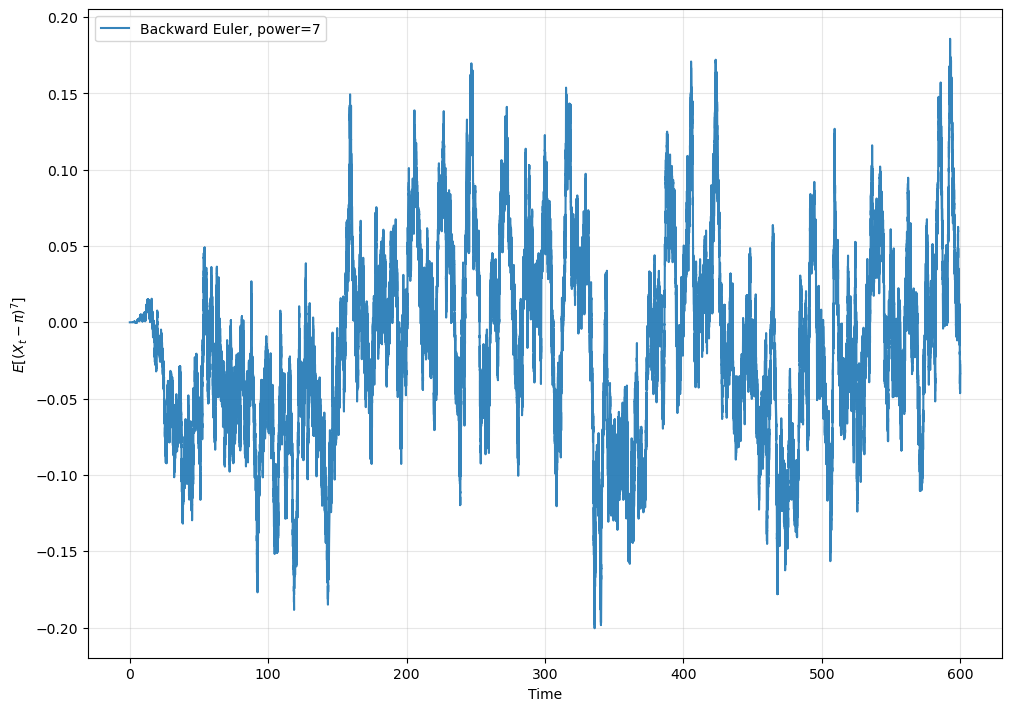

In [19]:
plot_moment_backward_only(moment_sum_IM_diff, n_paths, T)